<a target="_blank" href="https://colab.research.google.com/github/lukebarousse/Python_Data_Analytics_Course/blob/main/4_Problems/2_13_Matplotlib Format Charts.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [2]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

## 🟩 Subplots with Bar Charts (2.13.1)

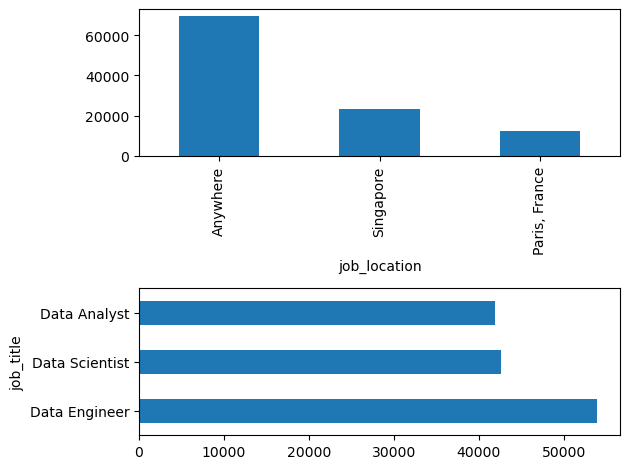

In [8]:
fig, ax = plt.subplots(2,1)
df_top_locations = df.groupby('job_location').size().sort_values(ascending=False).head(3)
df_top_locations.plot(kind='bar', ax=ax[0])
df_top_job_titles = df.groupby('job_title').size().sort_values(ascending=False).head(3)
df_top_job_titles.plot(kind='barh', ax=ax[1])
plt.tight_layout()
plt.show()

---

## 🟨 Subplots with Job Titles by Schedule (2.13.2)

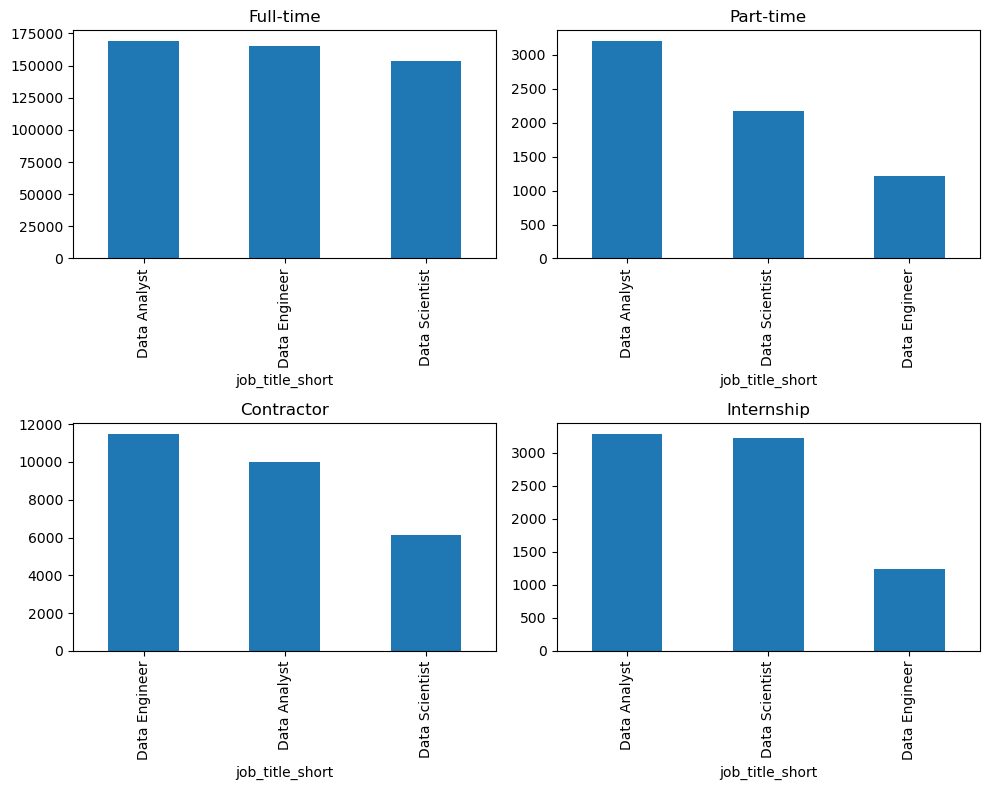

In [18]:
# Code Needed
# fig, ax = plt.subplots(2,2)
# df_full_time = df.groupby('job_title_short')[df['job_schedule_type'] == 'Full-time'].size().sort_values(ascending=False).head(3)
# df_part_time = df.groupby('job_title_short')[df['job_schedule_type'] == 'Part-time'].size().sort_values(ascending=False).head(3)
# df_contractor = df.groupby('job_title_short')[df['job_schedule_type'] == 'Contractor'].size().sort_values(ascending=False).head(3)
# df_internship = df.groupby('job_title_short')[df['job_schedule_type'] == 'Internship'].size().sort_values(ascending=False).head(3)

# df_full_time.plot(kind='bar', ax=ax[0,0], title='Full-time')
# df_part_time.plot(kind='bar', ax=ax[0,1], title='Part-time')
# df_contractor.plot(kind='bar', ax=ax[1,0], title='Contractor')
# df_internship.plot(kind='bar', ax=ax[1,1], title='Internship')
# plt.tight_layout()
# plt.show()

fig, ax = plt.subplots(2, 2, figsize=(10, 8))

df_full_time  = df[df['job_schedule_type'] == 'Full-time'].groupby('job_title_short').size().sort_values(ascending=False).head(3)
df_part_time  = df[df['job_schedule_type'] == 'Part-time'].groupby('job_title_short').size().sort_values(ascending=False).head(3)
df_contractor = df[df['job_schedule_type'] == 'Contractor'].groupby('job_title_short').size().sort_values(ascending=False).head(3)
df_internship = df[df['job_schedule_type'] == 'Internship'].groupby('job_title_short').size().sort_values(ascending=False).head(3)

df_full_time.plot(kind='bar',  ax=ax[0,0], title='Full-time')
df_part_time.plot(kind='bar',  ax=ax[0,1], title='Part-time')
df_contractor.plot(kind='bar', ax=ax[1,0], title='Contractor')
df_internship.plot(kind='bar', ax=ax[1,1], title='Internship')

plt.tight_layout()
plt.show()



---

## 🟥 Top Skills for Job Roles Subplots (2.13.3)

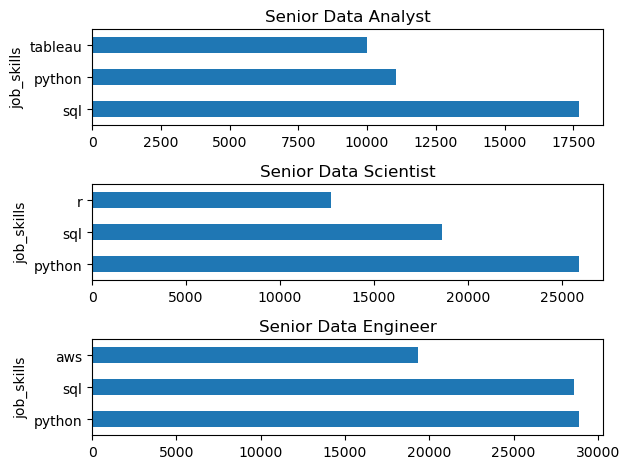

In [25]:
# Code Needed
df_role_skills = df.explode('job_skills')
job_roles = ['Senior Data Analyst', 'Senior Data Scientist', 'Senior Data Engineer']
fig, ax = plt.subplots(3, 1)
for i, role in enumerate(job_roles):
    df_role = df_role_skills[df_role_skills['job_title_short'] == role]['job_skills'].value_counts().head(3)
    df_role.plot(kind='barh', ax=ax[i], title=role)
    plt.tight_layout()
plt.show()  


---